# <font color="green"> **AI for Cybersecurity Project 2024-25 Group 9**

<font color="black">
Lamb Giovanni - 0622702168 <br>
Orlando Palma - 0622702433 <br>
Saturnino Fabrizio - 0622702328 <br>
Zottarelli Egidio - 0622702175



## **Contents**
1. Dataset Selection
2. Accuracy Evaluation of NN1
3. Adversarial Examples Generation

## **Import**

In [1]:
import torch
import shutil
import os
import random
import pickle
import art
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from datetime import datetime
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from facenet_pytorch import MTCNN
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescent, BasicIterativeMethod, FastGradientMethod, DeepFool, CarliniL2Method, CarliniLInfMethod

C:\Users\orlan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Utils

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define a transform pipeline: resize images to 224x224 and convert to tensor
transform = transforms.Compose([
    transforms.Resize((160, 160)), 
    transforms.ToTensor()
])

def load_image_noMTCNN(filename):
    """
    Loads an image from the given filename, resizes it, and converts it to a tensor.

    Args:
        filename (str): Path to the image file.

    Returns:
        torch.Tensor or None: Transformed image tensor, or None if loading fails.
    """
    try:
        img = Image.open(filename).convert("RGB")  
        return transform(img) 
    except Exception as e:
        print(f"Error loading image {filename}: {e}")  
        return None
    
def get_accuracy(model, x_test, y_test):
    """
    Evaluate the accuracy of a classification model on a test set.

    Args:
        model: The PyTorch model to evaluate.
        x_test: Test images (can be a list or tensor).
        y_test: True labels (list or array).

    Returns:
        accuracy: Classification accuracy (float).
        correct_predictions: Number of correct predictions (int).
        total_predictions: Total number of predictions (int).
    """
    model.eval()  # Set model to evaluation mode

    predictions = []
    true_values = []

    for x, y in zip(x_test, y_test):
        if x is None:
            print("None sample encountered")
            continue

        # Convert input to tensor and add batch dimension
        x_tensor = torch.tensor(x).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x_tensor)  # Get model output

        # Get predicted class (argmax over logits)
        pred_class = pred[0].detach().cpu().numpy().argmax()
        predictions.append(pred_class)
        true_values.append(y)
    
    # Save predictions and true values to CSV for later analysis
    results_df = pd.DataFrame({
        'Prediction': predictions,
        'True Value': true_values
    })
    results_df.to_csv("datasets/prediction_nn1.csv", index=False)

    # Calculate accuracy
    correct_predictions = sum(p == t for p, t in zip(predictions, true_values))
    total_predictions = len(true_values)
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

    return accuracy, correct_predictions, total_predictions

def plot_predicted_images(x_test, y_test: list, y_pred: list, title: str = "Plot Prediction",
                          id_test_images: list = [1, 4, 32, 33, 59, 73], label_to_name=None):
    """
    Plots a selection of images from x_test with their true and predicted labels.

    Args:
        x_test: Array or tensor of images (shape: [N, C, H, W]).
        y_test: List or array of true labels.
        y_pred: List or array of predicted labels.
        title: Title for the plot.
        id_test_images: List of indices of images to plot.
        label_to_name: Optional dict mapping label ids to names.
    """

    def invert_standardization(image):
        # If values are in [-1, 1], bring them back to [0, 1] for visualization
        return (image + 1) / 2 if image.min() < 0 else image

    # Convert x_test to numpy if it's a torch tensor
    if isinstance(x_test, torch.Tensor):
        x_test = x_test.cpu().numpy()
    
    x_test = invert_standardization(x_test)

    # Setup the plot grid
    num_images = len(id_test_images)
    rows = num_images // 3 + (num_images % 3 > 0)
    fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(21, 5 * rows))
    fig.suptitle(title, fontsize=21, color='black', backgroundcolor='#FFFF9b',
                 fontweight='bold', fontname='Comic Sans MS')

    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, idx in enumerate(id_test_images):
        if idx >= len(x_test):
            print(f"Index {idx} out of range.")
            continue

        # Convert image from [C, H, W] to [H, W, C] for imshow
        image = x_test[idx].transpose(1, 2, 0)
        np.clip(image, 0, 1, out=image)  # Ensure values are in [0, 1]

        true_label = y_test[idx]
        pred_label = y_pred[idx]

        true_id = int(true_label)
        pred_id = int(pred_label)

        true_name = label_to_name.get(true_id, true_id) if label_to_name else true_id
        pred_name = label_to_name.get(pred_id, pred_id) if label_to_name else pred_id

        ax = axes[i]
        ax.imshow(image)
        ax.set_title(f"True: {true_name}\nPred: {pred_name}")
        ax.axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

<a id="dataset_selection"></a>
## **1. Dataset Selection**

Choose 100 identities from the training set of the **VGG-Face2** dataset (<a href="https://drive.google.com/file/d/1SXhc8m5PHxyM4lEWVEccSufIa8OiOjGW/view?usp=sharing">link</a>) and construct a test set of at least 1000 images (at least 10 per identity), extracted from the dataset (<a href="https://drive.google.com/file/d/1K56kVYHHDfLA2Anm7ga0tQolMwIPk6R8/view?usp=sharing">link</a>) or found online.

> The dataset contains 3.31 million images of 9131 subjects (identities), with an average of 362.6 images for each subject. Images are downloaded from Google Image Search and have large variations in pose, age, illumination, ethnicity and profession (e.g. actors, athletes, politicians). The VGGFace2 consist of a training set (8631 images) and a validation set (500 images).

In [ ]:
# Set random seed for reproducibility
random.seed(42)

test_path = 'datasets/test'

# Randomly select 100 identities from the training set
identity_lst = random.sample(os.listdir('datasets/train'), 100)

# Create a folder for each selected identity in the test directory
for identity in identity_lst:
  os.makedirs(os.path.join(test_path, identity), exist_ok=True)

def copy_files(source_folder, destination_folder):
  # Randomly select 10 files from the source folder
  files = random.sample(os.listdir(source_folder), 10)
  print(files) 
  for file in files:
    source_path = os.path.join(source_folder, file)
    destination_path = os.path.join(destination_folder, file)
    # Copy each selected file to the destination folder
    shutil.copyfile(source_path, destination_path)

# For each selected identity, copy 10 random images from train to test
for identity in identity_lst:
  source_folder = f'datasets/train/{identity}'
  destination_folder = f'datasets/test/{identity}'
  copy_files(source_folder, destination_folder)

In [3]:
test_root = 'datasets/test'
test_path = 'datasets/test'

# List all identity folders in the test directory
identity_folders = [d for d in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, d))]

print(f"Number of identity in the test folders: {len(identity_folders)}")

# Check the number of image files in each identity folder
for identity in identity_folders:
    folder_path = os.path.join(test_root, identity)
    # Only count image files with specific extensions
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Warn if the folder does not contain exactly 10 images
    if len(files) != 10:
        print(f"Folder {identity} has {len(files)} files (expected 10)")
        
non_rgb_images = []

# Check each image in the test set for color mode
for identity in os.listdir(test_path):
    identity_path = os.path.join(test_path, identity)
    for image_name in os.listdir(identity_path):
        image_path = os.path.join(identity_path, image_name)
        try:
            with Image.open(image_path) as img:
                # If the image is not RGB, record its path and mode
                if img.mode != 'RGB':
                    non_rgb_images.append((image_path, img.mode))
        except Exception as e:
            print(f"Could not open {image_path}: {e}")

# Print summary of non-RGB images found
if not non_rgb_images:
    print("Non-RGB images not found")
else: 
    for path, mode in non_rgb_images:
        print(f"{path} - Mode: {mode}")


Number of identity in the test folders: 100
Non-RGB images not found


In [ ]:
# Load the original CSV file
df = pd.read_csv(
    filepath_or_buffer='datasets/identity_meta.csv',    # File path
    sep=',',                                            # Separator
    skipinitialspace=True,                              # Skip spaces after delimiter
    engine='python'                                     # Parser engine
)

df['Name'] = df['Name'].str.replace(',', '')
name_class_dict = df.set_index('Name')['Class_ID'].to_dict()

# Filter the DataFrame to keep only rows where Class_ID is in identity_lst
filtered_df = df[df['Class_ID'].isin(identity_lst)]

# Save the filtered DataFrame to a new CSV file
filtered_df.to_csv('datasets/test_meta.csv', index=False)


In [4]:
# Load labels from VGGFace
fpath = tf.keras.utils.get_file('rcmalli_vggface_labels_v2.npy',
                                "https://github.com/rcmalli/keras-vggface/releases/download/v2.0/rcmalli_vggface_labels_v2.npy",
                                cache_subdir="./")
LABELS = np.load(fpath)
LABELS = np.array([str(label).strip() for label in LABELS])  # Clean up whitespace

# Create a mapping from label index to name for all VGGFace2 classes
label_to_name_all = {i: LABELS[i] for i in range(len(LABELS))}
with open("datasets/label_to_name_all.pkl", "wb") as f:
    pickle.dump(label_to_name_all, f)

# Load your metadata CSV (the one with Class_ID, Name, etc.)ame, etc.)
meta_df = pd.read_csv(
    filepath_or_buffer='datasets/test_meta.csv',        # File path
    sep=',',                                            # Separator
    skipinitialspace=True,                              # Skip spaces after delimiter
    engine='python'                                     # Parser engine
)  

class_id_to_name = dict(zip(meta_df["Class_ID"], meta_df["Name"]))
# Prepare list of data entries
data = []
test_root = "datasets/test"

for identity in os.listdir(test_root):
    identity_path = os.path.join(test_root, identity)
    if not os.path.isdir(identity_path):
        continue
    name = class_id_to_name.get(identity, "Unknown")
    try:
        label = np.where(LABELS == name)[0][0]
    except IndexError:
        print(f"Warning: '{name}' not found in LABELS. Skipping.")
        continue
    for fname in os.listdir(identity_path):
        fpath = os.path.join(identity_path, fname).replace("/", "\\")  # match sample format
        data.append([fpath, identity, name, label])

# Save to CSV
df = pd.DataFrame(data, columns=["file_path", "identity", "name", "label"])
df.to_csv("datasets/test_dataset_labels.csv", index=False)


In [5]:
# Load the CSV file containing test labels
df_labels = pd.read_csv("datasets/test_dataset_labels.csv")
df_labels["label"] = df_labels["label"].astype(int)

# Create a partial mapping from label to name using the test CSV
label_to_name_partial = dict(zip(df_labels["label"], df_labels["name"]))

# Merge mappings: give priority to the test CSV, fallback to the official LABELS if missing
label_to_name = label_to_name_partial.copy()
for i, name in label_to_name_all.items():
    label_to_name.setdefault(i, name)  # Only add if not already present

<a id="accuracy_evaluation_of_NN1"></a>
## **2. Accuracy Evaluation of NN1**
Evaluate the accuracy of the provided face recognition network (henceforth referred to as NN1) on the constructed test set.

> **Model NN1: Inception Resnet V1**<br> We initialize an Inception Resnet V1 model for face recognition. The Inception Resnet V1 is a convolutional neural network (CNN) architecture that's been trained for face recognition. It's being imported from the ***facenet_pytorch*** library. The model is being initialized with pre-trained weights from the ***vggface2*** dataset, which is a large-scale face recognition dataset. The ***.eval()*** method is called to set the model in evaluation mode, which means it won't change the weights while making predictions. Finally, ***resnet.classify = True*** is setting the model to classification mode, which means it will return logits (the raw, non-normalized output of the last layer in the network) when making predictions.

In [6]:
nn1 = InceptionResnetV1(pretrained='vggface2').eval().to(device)
nn1.classify = True

In [7]:
# Load the CSV into a DataFrame
csv_path = 'datasets/test_dataset_labels.csv'
df = pd.read_csv(csv_path)

# Normalize file paths in the CSV to match OS format
df['file_path'] = df['file_path'].apply(lambda x: x.replace('\\', os.sep))

# Create a lookup dictionary: {file_path: label}
label_lookup = dict(zip(df['file_path'], df['label']))

# Initialize test data lists
test_path = 'datasets/test'
x_test = []
y_test = []

for folder in tqdm(os.listdir(test_path)):
    folder_path = os.path.join(test_path, folder)
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            img = load_image_noMTCNN(file_path)
            if img is not None:
                x_test.append(img)

                # Look up the label using normalized file path
                relative_path = os.path.normpath(file_path)  # normalize slashes
                label = label_lookup.get(relative_path)

                if label is not None:
                    y_test.append(label)
                else:
                    print(f"Warning: No label found for {file_path}")

100%|██████████| 100/100 [00:02<00:00, 47.57it/s]


### Evaluate the Test Set on the NN1

After converting the images into tensors with consistent dimensions, we can proceed to evaluate the model on the test set. Specifically, we will compare the predicted labels with the ground-truth labels to compute the model's accuracy. With properly preprocessed input images, the model is expected to perform reliably on the evaluation data.

In [ ]:
x_test_np = torch.stack(x_test).numpy()
y_test_np = np.array(y_test)

np.save('datasets/x_test_no_MTCNN.npy', x_test_np)
np.save('datasets/y_test_no_MTCNN.npy', y_test_np)

In [8]:
x_test = np.load('datasets/x_test_no_MTCNN.npy')
y_test = np.load('datasets/y_test_no_MTCNN.npy')

In [9]:
# Ensure all elements are tensors
x_test_tensor_only = [torch.tensor(img) if isinstance(img, np.ndarray) else img for img in x_test]

# Stack them into a single tensor
x_tensor = torch.stack(x_test_tensor_only)

# Compute min and max
overall_min = x_tensor.min().item()
overall_max = x_tensor.max().item()

print(f"Overall pixel range across x_test: min={overall_min}, max={overall_max}")

Overall pixel range across x_test: min=0.0, max=1.0


In [10]:
x_test_tensor = torch.from_numpy(x_test)
accuracy, correct_predictions, total_predictions = get_accuracy(nn1, x_test_tensor, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly classified: {correct_predictions}")
print(f"Incorrectly classified: {total_predictions - correct_predictions}")

C:\Users\orlan\AppData\Local\Temp\ipykernel_3100\614523211.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x).unsqueeze(0).to(device)


Accuracy: 87.00%
Correctly classified: 870
Incorrectly classified: 130


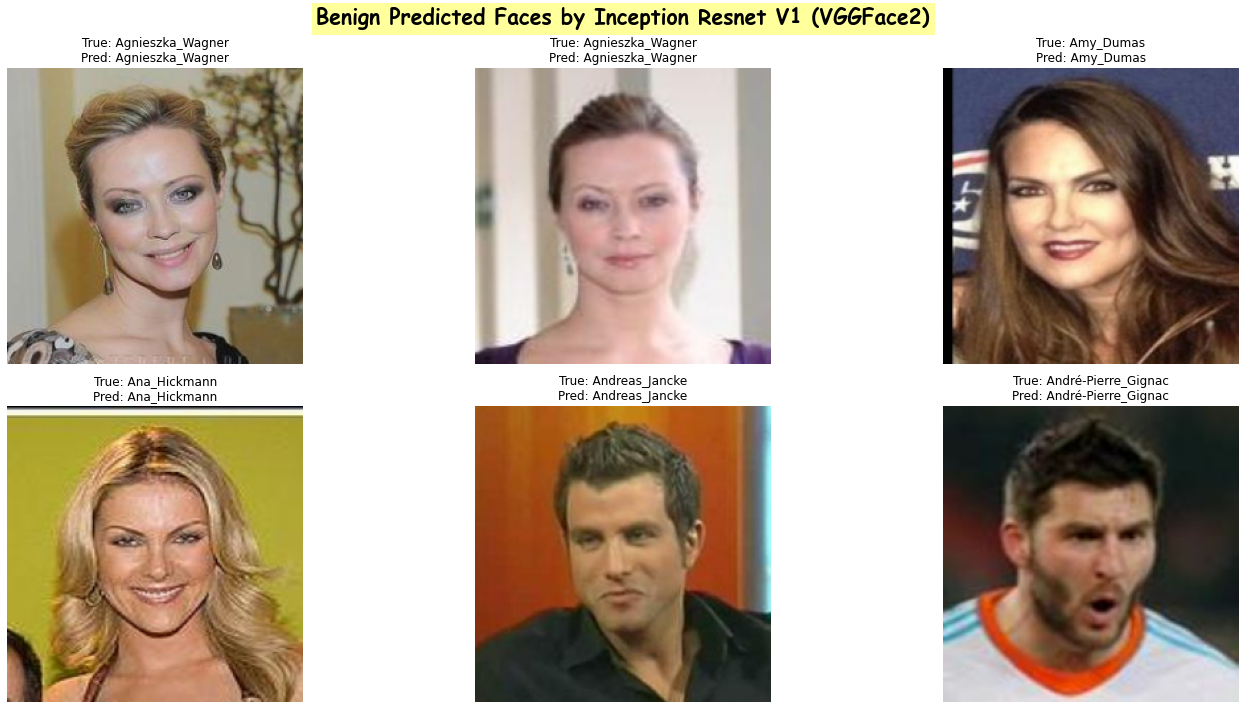

In [11]:
y_pred = pd.read_csv("datasets/prediction_nn1.csv")['Prediction'].tolist()

plot_predicted_images(x_test=x_test, y_test=y_test, y_pred=y_pred, title="Benign Predicted Faces by Inception Resnet V1 (VGGFace2)", id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name)

The **MTCNN** (Multi-task Cascaded Convolutional Networks) is an advanced deep learning framework used primarily for face detection and alignment in unconstrained environments. The complexity of these tasks arises from the variability in poses, illumination conditions, and potential occlusions. The `MTCNN` framework is particularly effective due to its multi-stage approach and the ability to exploit the correlations between face detection and facial landmark localization.

> **How MTCNN Works?** 
>
> MTCNN employs a *cascaded structure* composed of three stages of convolutional networks. Each stage is designed to progressively refine the detection and alignment process in a coarse-to-fine manner. This structure enables the network to efficiently handle the face detection and alignment tasks. Three Stages: 
> - **Stage 1**: Quickly proposes candidate windows that might contain faces.
> - **Stage 2**: Refines these candidate windows and rejects non-face regions, further narrowing down the search area.
> - **Stage 3**: Precisely locates the facial landmarks within the retained regions to ensure accurate alignment.

When used as part of a face recognition pipeline, such as with the InceptionResnetV1 model, **MTCNN** provides several advantages:

- **Face Detection and Preprocessing**: By directly feeding images to an MTCNN object in ***facenet-pytorch***, the module returns *torch tensors* containing the detected faces rather than just bounding boxes. This integration allows for seamless processing of faces, which can be directly used as input for further recognition steps.

- **Image Standardization**: MTCNN applies fixed image standardization to faces before returning them. This standardization ensures that the input faces are appropriately preprocessed for optimal performance with the face recognition model, such as ***InceptionResnetV1***. However, if needed, this normalization can be disabled by setting ***post_process=False*** when creating the detector, resulting in output images that are more visually normal.

- **Ease of Use**: The direct output of detected faces as tensors simplifies the pipeline, making it easier to integrate MTCNN as the initial stage of face recognition workflows. The preprocessed faces can be efficiently passed to subsequent networks or algorithms, streamlining the entire recognition process.

In [16]:
# Initialize the MTCNN model for face detection
mtcnn = MTCNN(
    image_size=160,                             # Image size (default: 160) for the model
    margin=32,                                  # Margin (default: 0) for the bounding box around the face
    min_face_size=20,                           # Minimum face size (default: 20) to detect
    thresholds=[0.6, 0.7, 0.7],                 # Thresholds (default: [0.6, 0.7, 0.7]) for the MTCNN
    factor=0.709,                               # Factor used to create a scaling pyramid of face sizes (default: {0.709})
    post_process=True,                          # Post-process (default: True) the MTCNN model in order to align faces
    select_largest=True,                        # Select the largest face in the image (default: True)
    selection_method="center_weighted_size",    # Which heuristic to use for selection (Default None)
    keep_all=False,                             # Keep all faces (default: False) found in the image
    device=device                               # Device (default: 'cuda') to use for the MTCNN model
)

# Define a preprocessing pipeline: resize image to 160x160 and convert to tensor
preprocess = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

def load_image(filename):
    """
    Loads an image from the given filename, detects and crops the face using MTCNN.
    If no face is detected, applies a fallback preprocessing (resize and tensor conversion).
    Returns a torch tensor of the cropped (or preprocessed) face.
    """
    img = Image.open(filename)
    img_cropped = mtcnn(img)  

    if img_cropped is None:
        print("No face detected in", filename)
        # Fallback: preprocess the whole image if no face is found
        img_cropped = preprocess(img)
        
    return img_cropped

In [17]:
# Load the CSV into a DataFrame
csv_path = 'datasets/test_dataset_labels.csv'
df = pd.read_csv(csv_path)

# Normalize file paths in the CSV to match OS format
df['file_path'] = df['file_path'].apply(lambda x: x.replace('\\', os.sep))

# Create a lookup dictionary: {file_path: label}
label_lookup = dict(zip(df['file_path'], df['label']))

# Initialize test data lists
test_path = 'datasets/test'
x_test = []
y_test = []

for folder in tqdm(os.listdir(test_path)):
    folder_path = os.path.join(test_path, folder)
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            img = load_image(file_path)
            if img is not None:
                x_test.append(img)

                # Look up the label using normalized file path
                relative_path = os.path.normpath(file_path)  # normalize slashes
                label = label_lookup.get(relative_path)

                if label is not None:
                    y_test.append(label)
                else:
                    print(f"Warning: No label found for {file_path}")

 10%|█         | 10/100 [00:16<02:06,  1.41s/it]

No face detected in datasets/test\n001140\0229_02.jpg


 24%|██▍       | 24/100 [00:37<01:53,  1.49s/it]

No face detected in datasets/test\n002007\0242_01.jpg


100%|██████████| 100/100 [01:52<00:00,  1.12s/it]


In [ ]:
x_test_np = torch.stack(x_test).numpy()
y_test_np = np.array(y_test)

np.save('datasets/x_test_32.npy', x_test_np)
np.save('datasets/y_test_32.npy', y_test_np)

In [21]:
x_test = np.load('datasets/x_test_32.npy')
y_test = np.load('datasets/y_test_32.npy')

In [22]:
# Ensure all elements are tensors
x_test_tensor_only = [torch.tensor(img) if isinstance(img, np.ndarray) else img for img in x_test]

# Stack them into a single tensor
x_tensor = torch.stack(x_test_tensor_only)

# Compute min and max
overall_min = x_tensor.min().item()
overall_max = x_tensor.max().item()

print(f"Overall pixel range across x_test: min={overall_min}, max={overall_max}")


Overall pixel range across x_test: min=-0.99609375, max=1.0


### Evaluate the Test Set on the NN1

After aligning the faces with the MTCNN model, we can proceed to evaluate the model on the test set. In particular, we will evaluate the model on the test set and calculate the accuracy of the model. By comparing the true and predicted labels, we can calculate the accuracy of the model on the test set. Having aligned the faces, the performance of the model should be improved.

####  Comparison of using margin = 0 and margin = 32 in MTCNN

In [20]:
# margin=0 
x_test_tensor = torch.from_numpy(x_test)
accuracy, correct_predictions, total_predictions = get_accuracy(nn1, x_test_tensor, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly classified: {correct_predictions}")
print(f"Incorrectly classified: {total_predictions - correct_predictions}") 

C:\Users\orlan\AppData\Local\Temp\ipykernel_7500\220585648.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x).unsqueeze(0).to(device)


Accuracy: 91.90%
Correctly classified: 919
Incorrectly classified: 81


In [23]:
# margin=32 
x_test_tensor = torch.from_numpy(x_test)
accuracy, correct_predictions, total_predictions = get_accuracy(nn1, x_test_tensor, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly classified: {correct_predictions}")
print(f"Incorrectly classified: {total_predictions - correct_predictions}") 

C:\Users\orlan\AppData\Local\Temp\ipykernel_7500\220585648.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x).unsqueeze(0).to(device)


Accuracy: 95.80%
Correctly classified: 958
Incorrectly classified: 42


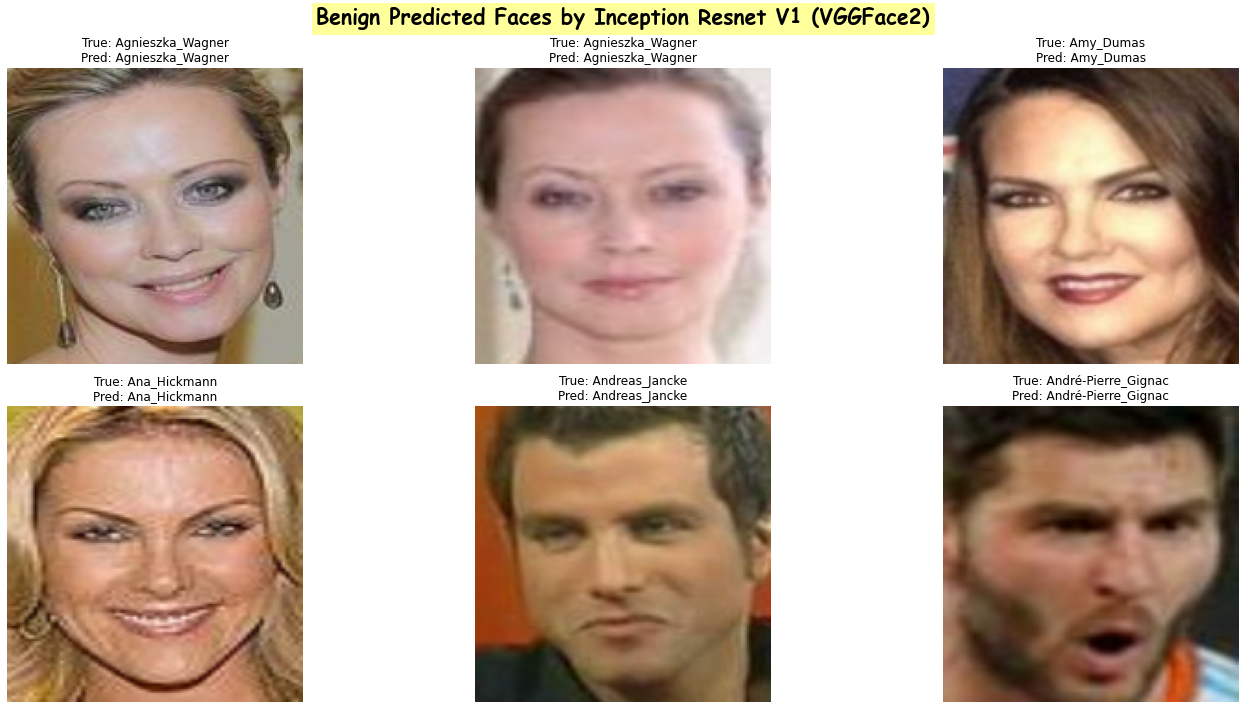

In [24]:
y_pred = pd.read_csv("datasets/prediction_nn1.csv")['Prediction'].tolist()

plot_predicted_images(x_test=x_test, y_test=y_test, y_pred=y_pred, title="Benign Predicted Faces by Inception Resnet V1 (VGGFace2)", id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name)

<a id = "adversial_examples_generation"></a>
## **3. Adversarial Examples Generation**
In this segment, we delve into the intriguing realm of adversarial attacks in machine learning models. **Adversarial examples** are crafted inputs intentionally designed to deceive models, leading to erroneous predictions. Understanding the generation and implications of adversarial examples is crucial for fortifying machine learning systems against potential vulnerabilities.

In the following script, we employ the powerful tools provided by the ***Adversarial Robustness Toolbox (ART)*** to explore the generation of adversarial examples. Leveraging the ***ARTAttackWrapper***, we showcase the process of crafting adversarial inputs for a PyTorch classifier, specifically utilizing the ***Inception ResNet V1 model*** (NN1).

In [ ]:
class ExperimentManager:
  def __init__(self, attacker, param_name, param_values, victim=None, preprocess=None, save_path=".", save_adv_samples=True):
    """
    Initialize the ExperimentManager.

    attacker: attack object
    param_name: name of the attack parameter to vary
    param_values: list of values for the parameter
    victim: optional victim model (if different from attacker's estimator)
    preprocess: optional preprocessing function for victim model
    save_path: directory to save results
    save_adv_samples: whether to save adversarial samples
    """
    self._attacker = attacker
    self._victim = victim if victim is not None else attacker.estimator
    self.param_name = param_name
    self.param_values = param_values
    self.save_path = save_path
    self._data = None
    self.save_adv_samples = save_adv_samples
    self._adv_samples = None
    self.preprocess = preprocess if victim is not None else None
    if victim is not None and preprocess is None:
      raise ValueError("You must specify a preprocessing function if you pass a victim model.")

  @property
  def experiment_name(self):
    """
    Generate a unique experiment name based on attack, parameter, and timestamp.
    """
    attack_name = self._attacker.__class__.__name__.lower()
    return f"{attack_name}_{self.param_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

  @property
  def adversarial_samples(self):
    """
    Return the generated adversarial samples.
    """
    return self._adv_samples

  @property
  def security_evaluation_data(self):
    """
    Return the collected experiment data.
    """
    return self._data

  def set_param_name(self, param_name):
    """
    Set the parameter name to vary.
    """
    self.param_name = param_name

  def set_param_values(self, param_values):
    """
    Set the list of parameter values to test.
    """
    self.param_values = param_values

  def save(self, experiment_name=None):
    """
    Save experiment data to a pickle file.
    """
    if experiment_name is None:
      experiment_name = self.experiment_name
    os.makedirs(self.save_path, exist_ok=True)
    with open(os.path.join(self.save_path, f"{experiment_name}.pkl"), 'wb') as file:
      pickle.dump(self._data, file)

  def run(self, x_test, y_test, targeted=False, target_class=None, num_classes=None, norm='inf', save_run=True, experiment_name=None):
    """
    Run the experiment by varying the attack parameter and collecting results.

    x_test: test samples
    y_test: test labels
    targeted: whether to run a targeted attack
    target_class: class to target (if targeted)
    num_classes: number of classes (for one-hot encoding)
    norm: norm to use for perturbation calculation
    save_run: whether to save results after run
    experiment_name: custom experiment name
    """
    self._data = {
      'param_values': self.param_values,
      'norm': None,
      'nb_pred': len(x_test),
    }

    if experiment_name is None:
      experiment_name = self.experiment_name

    n_runs = len(self.param_values)
    nb_correct = []
    perturbation = [None] * n_runs
    self._adv_samples = [None] * n_runs if self.save_adv_samples else None

    # Special handling for DeepFool attack
    if isinstance(self._attacker, DeepFool):
      perturbation_mean = [None] * n_runs
      for run, param_value in enumerate(self.param_values):
        print(f"\n Esecuzione DeepFool con {self.param_name}={param_value}")
        self._attacker.set_params(**{self.param_name: param_value})
        adv_samples = []
        correct = 0
        pert_list = []

        for i in range(len(x_test)):
          x_i = x_test[i:i+1]
          y_i = y_test[i]

          x_adv = self._attacker.generate(x_i)
          adv_samples.append(x_adv[0])

          x_adv_tensor = torch.from_numpy(x_adv[0]).unsqueeze(0).to(device)
          with torch.no_grad():
            output = nn1(x_adv_tensor)
          pred = torch.argmax(output, dim=1).item()

          if pred == y_i:
            correct += 1

          pert_list.append(np.max(np.abs(x_adv[0] - x_i[0])))

        adv_samples = np.array(adv_samples)
        pert_list = np.array(pert_list)

        if self.save_adv_samples:
          self._adv_samples[run] = adv_samples

        nb_correct.append(correct)
        perturbation[run] = np.max(pert_list)
        perturbation_mean[run] = np.mean(pert_list)

        # Extra diagnostics
        n_valid = np.sum(pert_list < 0.1)
        print(f"→ {n_valid}/{len(pert_list)} immagini con L∞ < 0.1")
        print(f"   {self.param_name} = {param_value}")
        print(f"   Perturbazione media = {perturbation_mean[run]:.4f}, massima = {pert_list.max():.4f}")

      self._data['nb_correct'] = nb_correct
      self._data['perturbation'] = perturbation
      self._data['perturbation_mean'] = perturbation_mean

    else:
      nb_correct_targeted = [None] * n_runs if targeted else None
      for i, param_value in tqdm(enumerate(self.param_values), total=n_runs):
        self._attacker.set_params(**{self.param_name: param_value})

        if targeted:
          # Prepare targeted labels for attack
          targeted_labels = target_class * np.ones(len(y_test))
          one_hot_targeted_labels = tf.keras.utils.to_categorical(targeted_labels, num_classes=num_classes)
          x_test_adv = self._attacker.generate(np.array(x_test), one_hot_targeted_labels)
        else:
          x_test_adv = self._attacker.generate(np.array(x_test))

        if self.save_adv_samples:
          self._adv_samples[i] = x_test_adv
          # Compute perturbation according to specified norm
          if norm == 1:
            perturbation[i] = np.mean(np.abs(x_test_adv - x_test))
          elif norm == 2:
            perturbation[i] = np.linalg.norm(x_test_adv - x_test)
          elif norm == 'inf':
            perturbation[i] = np.max(np.abs(x_test_adv - x_test))

        # Predict on adversarial samples
        x_test_adv_pred = np.argmax(self._victim.predict(
          self.preprocess(x_test_adv) if self._victim != self._attacker.estimator else x_test_adv), axis=1)

        nb_correct[i] = np.sum(x_test_adv_pred == np.array(y_test))

        if targeted:
          nb_correct_targeted[i] = np.sum(x_test_adv_pred == target_class)

      self._data['perturbation'] = perturbation
      self._data['nb_correct'] = nb_correct
      if targeted:
        self._data['nb_correct_targeted'] = nb_correct_targeted

    if save_run:
      self.save(experiment_name)

  def plot(self, save=False):
    """
    Plot the security evaluation curve and perturbation curve.

    save: whether to save the plots as PNG files
    """
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots()
    y_values = 100 * (np.array(self._data['nb_correct']) / self._data['nb_pred'])
    ax.plot(np.array(self.param_values), y_values, 'r--', label='Classifier')

    if 'nb_correct_targeted' in self._data and self._data['nb_correct_targeted'] is not None:
      y_values_targeted = 100 * (np.array(self._data['nb_correct_targeted']) / self._data['nb_pred'])
      ax.plot(np.array(self.param_values), y_values_targeted, 'b--', label='Target Class')

    plt.xlabel(self.param_name)
    plt.ylabel("Accuracy (%)")
    ax.legend(loc='upper right', fontsize='large', frameon=True, edgecolor='black')
    ax.grid(True)
    plt.title('Security Evaluation Curve')
    plt.show()

    if save:
      plt.savefig(os.path.join(self.save_path, f"{self.experiment_name}.png"))

    # Perturbation plot
    if 'perturbation' in self._data and self._data['perturbation'] is not None:
      fig2, ax2 = plt.subplots()
      ax2.plot(np.array(self.param_values), np.array(self._data['perturbation']), 'g--', label='L∞ Perturbation')
      ax2.set_xlabel(self.param_name)
      ax2.set_ylabel("L∞ Perturbation Magnitude")
      ax2.set_title("Perturbation Curve")
      ax2.legend(loc='upper left', fontsize='large', frameon=True, edgecolor='black')
      ax2.grid(True)
      plt.show()

      import matplotlib.ticker as ticker
      ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
      ax2.ticklabel_format(style='plain', axis='y')  
      ax2.get_yaxis().get_offset_text().set_visible(False)

      if save:
        plt.savefig(os.path.join(self.save_path, f"{self.experiment_name}_perturbation.png"))


In [26]:
# Initialize the classifier with the Inception Resnet V1 model
target_class = 1050
num_classes = 8631

classifier = PyTorchClassifier(
    model=nn1,                                                     # The PyTorch model to use
    clip_values=(-1, 1),                                           # The minimum and maximum values of the input                        
    loss=torch.nn.CrossEntropyLoss(),                              # The loss function
    optimizer=torch.optim.Adam(nn1.parameters(), lr=0.001),        # The optimizer
    input_shape=(3, 160, 160),                                     # The shape of the input
    nb_classes=num_classes,                                        # The number of classes
)

<a id = "fast gradient sign method "></a>
### **Fast Gradient Sign Method (FGSM)**
 This technique perturbs the input data by adding small, carefully crafted perturbations scaled by the sign of the gradient of the loss function with respect to the input. Despite its simplicity, fgsm often achieves effective adversarial perturbations.

#### FGSM Untargeted

In [9]:
eps_range = np.linspace(0, 0.1, 10)

In [ ]:
attack = FastGradientMethod(estimator=classifier, targeted=False)
sec_eval = ExperimentManager(
    attack,
    param_name="eps",
    param_values=eps_range,
    save_path='attacks/FGSM/FGSM_untargeted/nn1'
)

sec_eval.run(
    x_test, 
    y_test, 
    save_run=True, 
    experiment_name='nn1_fgsm_untargeted_eps_0_to_0.1'
)

In [ ]:
perturbations = sec_eval.security_evaluation_data['perturbation']
for eps, pert in zip(sec_eval.param_values, perturbations):
    print(f"Epsilon: {eps}, Perturbation: {pert}")

In [12]:
# Set threshold
linf_threshold = 0.1

# Choose which run/epsilon to inspect (e.g., index 0)
i = 9
x_adv = sec_eval.adversarial_samples[i]
x_orig = x_test[0:10]

# Find violating samples
violating_indices = []
for idx in range(len(x_orig)):
    diff = np.abs(x_adv[idx] - x_orig[idx])
    if np.max(diff) > linf_threshold:
        violating_indices.append(idx)

print(f"Found {len(violating_indices)} samples violating L∞ constraint of 0.1 at eps={sec_eval.param_values[i]}")


Found 10 samples violating L∞ constraint of 0.1 at eps=0.1


In [ ]:
sec_eval.plot()

In [ ]:
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Generic Case - Adversarial Examples by FGSM with ε = {sec_eval.param_values[i]:.3f}",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)


#### FGSM Targeted

In [15]:
eps_range = np.linspace(0, 0.1, 10)

In [ ]:
attack = FastGradientMethod(estimator=classifier, targeted=True)

sec_eval = ExperimentManager(
    attack,  
    param_name="eps", 
    param_values=eps_range, 
    save_path='attacks/FGSM/FGSM_targeted/nn1'
)

sec_eval.run(
    x_test, 
    y_test, 
    targeted = True, 
    target_class = target_class, 
    num_classes = num_classes, 
    experiment_name='nn1_fgsm_targeted_eps_0_to_0.1'
)

In [ ]:
perturbations = sec_eval.security_evaluation_data['perturbation']
for eps, pert in zip(sec_eval.param_values, perturbations):
    print(f"Epsilon: {eps}, Perturbation: {pert}")

In [ ]:
sec_eval.plot()

In [ ]:
i = 9
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Specific Case - Adversarial Examples by FGSM with ε = {sec_eval.param_values[i]:.3f}",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

### **Basic Iterative Method (BIM)**
BIM is an iterative variant of the bim attack. It applies multiple small perturbations to the input data, each time computing the gradient of the loss function with respect to the perturbed input. By iteratively refining the perturbations, BIM enhances the effectiveness of the attack.

#### BIM Untargeted

In [20]:
eps_step = 0.001
max_iter = 100
eps_range = np.linspace(0, 0.1, 10)

In [ ]:
attack = BasicIterativeMethod(
    estimator=classifier,
    eps_step=eps_step,
    max_iter=max_iter,
    targeted=False
)

sec_eval = ExperimentManager(
    attack,
    param_name = "eps",
    param_values=eps_range, 
    save_path='attacks/BIM/BIM_untargeted/nn1'
)

sec_eval.run(
    x_test, 
    y_test, 
    save_run=True,
    experiment_name='nn1_bim_untargeted_eps_0_to_0.1_epsstep_0.001_maxiter_100')

In [ ]:
perturbations = sec_eval.security_evaluation_data['perturbation']
for eps, pert in zip(sec_eval.param_values, perturbations):
    print(f"Epsilon: {eps}, Perturbation: {pert}")

In [ ]:
sec_eval.plot()

In [ ]:
i = 9
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-General Case - Adversarial Examples by BIM with ε = {sec_eval.param_values[i]:.3f}",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

#### BIM Targeted

In [ ]:
eps_step = 0.001
max_iter = 100
eps_range = np.linspace(0, 0.1, 10)

In [ ]:
attack = BasicIterativeMethod(
  estimator=classifier,
  eps_step=eps_step,
  max_iter=max_iter,
  targeted=True
)

sec_eval = ExperimentManager(
  attacker=attack,
  param_name="eps",
  param_values=eps_range,
  save_path='attacks/BIM/BIM_targeted/nn1'
)

sec_eval.run(
  x_test,
  y_test,
  targeted = True,
  target_class = target_class,
  num_classes = num_classes,
  experiment_name='nn1_bim_targeted_eps_0_to_0.1_epsstep_0.001_maxiter_100'
)

In [ ]:
perturbations = sec_eval.security_evaluation_data['perturbation']
for eps, pert in zip(sec_eval.param_values, perturbations):
    print(f"Epsilon: {eps}, Perturbation: {pert}")

In [ ]:
sec_eval.plot()

In [ ]:
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Specific Case - Adversarial Examples by BIM with ε = {sec_eval.param_values[i]:.3f}",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

### **Projected Gradient Descent (PGD)**
Unlike BIM, PGD performs a more sophisticated iterative optimization process. It repeatedly applies small, controlled perturbations while projecting the result back into the allowed epsilon ball around the original input, ensuring the adversarial examples stay within a permissible range.

#### PGD Untargeted

In [32]:
eps_step = 0.01
max_iter = 10
num_random_init = 0
eps_range = np.linspace(0, 0.1, 10)

In [ ]:
attack = ProjectedGradientDescent(
  estimator=classifier,
  eps_step=eps_step,
  max_iter=max_iter,
  num_random_init=num_random_init,
  targeted=False
)
sec_eval = ExperimentManager(
  attack,
  "eps",
  eps_range,
  save_path='attacks/PGD/PGD_untargeted/nn1'
)

sec_eval.run(
  x_test, 
  y_test, 
  save_run=True, 
  experiment_name='nn1_pgd_untargeted_eps_0_to_0.1_steps10_epsstep0.01_maxiter10_randominit_01'
)

In [ ]:
sec_eval.plot()

In [ ]:
i = 9
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Generic Case - Adversarial Examples by PGD with ε = {sec_eval.param_values[i]:.3f}",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

#### PGD Targeted

In [36]:
eps_step = 0.01
max_iter = 10
num_random_init = 0
eps_range = np.linspace(0, 0.1, 10)

In [ ]:
attack = ProjectedGradientDescent(
    estimator=classifier,
    eps_step=eps_step,
    max_iter=max_iter,
    num_random_init=num_random_init,
    targeted = True
)

sec_eval = ExperimentManager(
    attack,
    "eps",
    eps_range,
    save_path='attacks/PGD/PGD_targeted/nn1'
)

sec_eval.run(
    x_test,
    y_test,
    targeted = True,
    target_class = target_class,
    num_classes = num_classes,
    experiment_name= 'nn1_pgd_targeted_eps_0_to_0.1_steps10_epsstep0.01_maxiter_10_randominit_0'
)

In [ ]:
sec_eval.plot()

In [ ]:
i = 9
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Specific Case - Adversarial Examples by PGD with ε = {sec_eval.param_values[i]:.3f}",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

### **DeepFool**
DeepFool is an iterative technique that aims to find the minimal perturbation required to mislead the classifier. By iteratively linearizing the decision boundaries of the model, DeepFool computes perturbations that cause misclassification with minimal changes to the input.


In [ ]:
epsilon = 1e-06
max_iter = 1
nb_grads = 12
batch_size = 20
max_iter_range = [1, 2, 3]

In [ ]:
attack = DeepFool(
    classifier=classifier, 
    epsilon = epsilon,
    max_iter=max_iter,
    nb_grads=nb_grads,
    batch_size = batch_size
)

sec_eval = ExperimentManager(
    attack, 
    param_name="max_iter", 
    param_values=max_iter_range, 
    save_path='attacks/DeepFool/nn1'
)

sec_eval.run(
    x_test, 
    y_test, 
    save_run=True, 
    experiment_name='nn1_deepfool_nbgrads12_eps1e-06_maxiter_1_to_3'
)

In [ ]:
sec_eval.plot()

In [ ]:
i = 0
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Adversarial Examples by DeepFool",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

### **Carlini & Wagner**
The C&W Attack formulates the generation of adversarial examples as an optimization problem, aiming to find the smallest perturbation that leads to misclassification while adhering to certain constraints. It offers strong adversarial perturbations capable of evading detection.

#### Carlini & Wagner L2 Targeted

In [ ]:
binary_search_steps = 1
learning_rate = 0.05
initial_const = 0.5
confidence=0.1
max_iter_range = [1,3,5,7,9,11]

In [ ]:
attack = CarliniL2Method(
    classifier=classifier,
    confidence=confidence,
    binary_search_steps=binary_search_steps,
    learning_rate=learning_rate,
    initial_const=initial_const,
    targeted=True)

sec_eval = ExperimentManager(
    attack, 
    "max_iter", 
    max_iter_range,
    save_path='attacks/CW/CW_targeted/nn1'
)

sec_eval.run(
    x_test, 
    y_test, 
    targeted = True, 
    target_class = target_class, 
    num_classes = num_classes,
    experiment_name='nn1_carlini_targeted_learningrate_0.05_initial_const_0.5_confidence_0.1_max_iter_1_to_7'
)


In [ ]:
sec_eval.plot()

In [ ]:
i = 5
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Specific Case - Adversarial Examples by Carlini&Wagner L2",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)

#### Carlini & Wagner LInf Untargeted

In [ ]:
learning_rate = [0.1, 0.04, 0.035, 0.025, 0.05]
initial_const = 0.01
confidence = 0.1
max_iter_range = [1, 2, 3, 5, 7]
decrese_factor = [0.9, 0.8, 0.8, 0.8, 0.8]
largest_const = [5.0, 8.0, 8.0, 8.0, 8.0]
const_factor = [1.2, 2.0, 2.0, 2.0, 2.0]
batch_size = [8, 32, 32, 32, 64]

In [ ]:
max_element= []
for max_iter, learning_rate, decrese_factor, largest_const, const_factor, batch_size in zip(max_iter_range, learning_rate, decrese_factor, largest_const, const_factor, batch_size):
    max_element.append(max_iter)
    attack = CarliniLInfMethod(
      classifier=classifier,
      confidence=confidence,
      learning_rate=learning_rate,
      initial_const=initial_const,
      decrease_factor=decrese_factor,
      largest_const=largest_const,
      const_factor=const_factor,
      batch_size = batch_size,
      targeted=False)
    sec_eval = ExperimentManager(
        attack, 
        "max_iter", 
        max_element,
        save_path='attacks/CW/CW_untargeted/nn1')
    sec_eval.run(
        x_test, 
        y_test, 
        save_run = True,
        experiment_name='nn1_carlini_untargeted_learningrate_0.1_to_0.05_initial_const_0.01_confidence_0.1_max_iter_1_to_7_decrease_factor_0.9_to_0.8_largest_const_5_to_8_const_factor_1.2_to_2_batch_size_8_to_64'
        )
    sec_eval.plot()
    max_element.clear()

In [ ]:
i = 5
x_adv = sec_eval.adversarial_samples[i]
y_pred_adv = classifier.predict(x_adv)
y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
y_true = y_test[:len(x_adv)]


plot_predicted_images(
    x_test=torch.tensor(x_adv),
    y_test=y_true,
    y_pred=y_pred_adv_labels,
    title=f"Error-Generic Case - Adversarial Examples by Carlini&Wagner LInf",
    id_test_images=[0, 3, 12, 25, 33, 52],
    label_to_name=label_to_name
)